In [1]:
# Necessary imports
%env CUDA_VISIBLE_DEVICES = 2
import os
import sys
sys.path.insert(0, "../../batchflow")

import warnings
from functools import partial
warnings.filterwarnings('ignore')

import numpy as np
import torch.nn as nn
from matplotlib import pyplot as plt
plt.style.use('ggplot')


from batchflow import B, M, P, R, V, Notifier, Pipeline
from batchflow import set_gpus
from batchflow.plotter import plot
from batchflow.models.torch import TorchModel, ResBlock
from batchflow.models.torch.unet import UNet
from batchflow.models.torch.blocks import BottleneckBlock
from batchflow.opensets.pascal import PascalSegmentation
from batchflow.opensets.coco import COCOSegmentation
from batchflow.opensets import PascalSegmentation
from batchflow import Batch, Pipeline, B, V, C, apply_parallel, ImagesBatch, action

from nbtools import pylint_notebook
from batchflow.opensets import ImagesOpenset

env: CUDA_VISIBLE_DEVICES=2


In [2]:
#?ImagesBatch.rotate

In [3]:
!nvidia-smi

Tue Mar 14 15:42:40 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.56.06    Driver Version: 520.56.06    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  Off  | 00000000:1A:00.0 Off |                  N/A |
| 26%   22C    P8     1W / 260W |   6241MiB / 11264MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  Off  | 00000000:1B:00.0 Off |                  N/A |
| 27%   

### Load Pascal dataset 

In [4]:
dataset = PascalSegmentation(train_test=False)
len(dataset.train), len(dataset.test)

(1464, 1449)

In [5]:
dataset.split(shares=0.9, shuffle=1)

In [6]:
len(dataset.train)

2622

In [7]:
# Set Parameters
IMAGE_SHAPE = (256, 256)

NUM_EPOCHS = 50
FREQUENCY = 10
BATCH_SIZE = 16

NUM_CLASSES = len(dataset.classes)
NUM_CLASSES

21

### Set the model 

In [8]:
config_res_unet_autoencoder = {
    'inputs_shapes': (3, *IMAGE_SHAPE),
    'order': ['encoder', 'embedding', 'decoder', 'head'],
    'encoder': {
        'type': 'encoder',
        'num_stages': 4,
        'order': ['block', 'downsample'],
        'blocks': {
            'base_block': ResBlock,
            'downsample': False, # aplly downsample after the ResBlock using the max pool 
            #'layout': 'Rcna cn+a',
            'channels': [64, 128, 256, 512],
            'bias': False,
            'branch': {
                'layout': 'cn',
                #'pool_size': 2,
                #'pool_stride': 2,
                'kernel_size': 1,
                'stride': 1, 
                'channels': [64, 128, 256, 512],
                'bias': False 
            },
        'output_type': 'list'
        }
    },
    'embedding': {
        'input_type': 'list',
        'output_type': 'list',
        'base_block': ResBlock, 
        'channels': 1024,
        'bias': False
    },
    'decoder': {
        'type': 'decoder',
        'output_type': 'list',
        'num_stages': 4,
        'skip': False,
        'order': ['upsample', 'block'],
        'blocks': {
            'base_block': ResBlock, 
            'channels': [512, 256, 128, 64],
            'bias': False
        },
        'upsample': {
            'layout': 't',
            'kernel_size': 2,
            'stride': 2,
            'channels': 'same',
            'bias': True
        }
    },
    'head': {         
        'layout': 'c',
        'channels': NUM_CLASSES,
        'kernel_size': 1,
        'stride': 1,
        'padding': 0 
    },
    'loss': 'ce',
    'optimizer': {'name': 'Adam', 'lr': 1e-4},
    'device': 'gpu:0'
}

In [9]:
model = TorchModel(config=config_res_unet_autoencoder)
model.repr(3, show_num_parameters=True)

Network(
    (encoder): EncoderModule(
        (block-0): Block:ResBlock(
            (repeat0-args0:  (?,   3, 256, 256)  ⟶ (?,  64, 256, 256), #params=39,168)
        (downsample-0): Downsample(
            (repeat0:  (?,  64, 256, 256)  ⟶ (?,  64, 128, 128), #params=0)
        )
        (block-1): Block:ResBlock(
            (repeat0-args0:  (?,  64, 128, 128)  ⟶ (?, 128, 128, 128), #params=230,144)
        (downsample-1): Downsample(
            (repeat0:  (?, 128, 128, 128)  ⟶ (?, 128,  64,  64), #params=0)
        )
        (block-2): Block:ResBlock(
            (repeat0-args0:  (?, 128,  64,  64)  ⟶ (?, 256,  64,  64), #params=919,040)
        (downsample-2): Downsample(
            (repeat0:  (?, 256,  64,  64)  ⟶ (?, 256,  32,  32), #params=0)
        )
        (block-3): Block:ResBlock(
            (repeat0-args0:  (?, 256,  32,  32)  ⟶ (?, 512,  32,  32), #params=3,673,088)
        (downsample-3): Downsample(
            (repeat0:  (?, 512,  32,  32)  ⟶ (?, 512,  16,  16), #

### Form the train pipeline 

In [10]:
def squeeze_batch(batch):
    return batch.squeeze(1)

def change_background(batch):
    batch.my_labels[batch.my_labels == 255] = 0
    return batch

In [11]:
load_pipeline = (
    Pipeline()
    .resize(size=IMAGE_SHAPE, src='images', dst='images')
    .resize(size=IMAGE_SHAPE, src='labels', dst='my_labels')
    .to_array(channels='first', src='images', dst='images', dtype=np.float32)
    .to_array(channels=None, src='my_labels', dst='my_labels', dtype=np.float32) 
    .change_background(B())
    #.squeeze_batch(B())
    .multiply(multiplier=1/255, src='images')
)

augmentations_pipeline = (
    Pipeline()
    #.scale(factor=1.5, src=['images', 'labels'], dst=['images', 'labels'], preserve_shape=True, p=0.5) # P(R('uniform', 0.5, 1, size=1))
    #.flip(mode=P(R(['lr', 'ud'])), src=['images', 'labels'], dst=['images', 'labels'], p=0.5)
    #.rotate(angle=P(R([90, 60])), src=['images', 'labels'], dst=['images', 'labels'], p=0.5)
    #.crop(origin='top_left', shape=(100, 100), src=['images', 'labels'], dst=['images', 'labels'])
)

train_model_pipeline = (
    Pipeline()
    .init_model('unet', model_class=UNet, mode='dynamic', config=config_res_unet_autoencoder)
    .init_variable('train_loss', [])
    .train_model('unet', inputs=B('images'), targets=B('my_labels'), outputs='loss', save_to=V('train_loss', mode='a'))
)

main_pipeline = (augmentations_pipeline + load_pipeline + train_model_pipeline) << dataset.train

### Plot images from the pipeline

In [12]:
batch = main_pipeline.next_batch(4, shuffle=True)
images = batch.images.transpose((0, 2, 3, 1))
masks = batch.my_labels
images.shape

(4, 256, 256, 3)

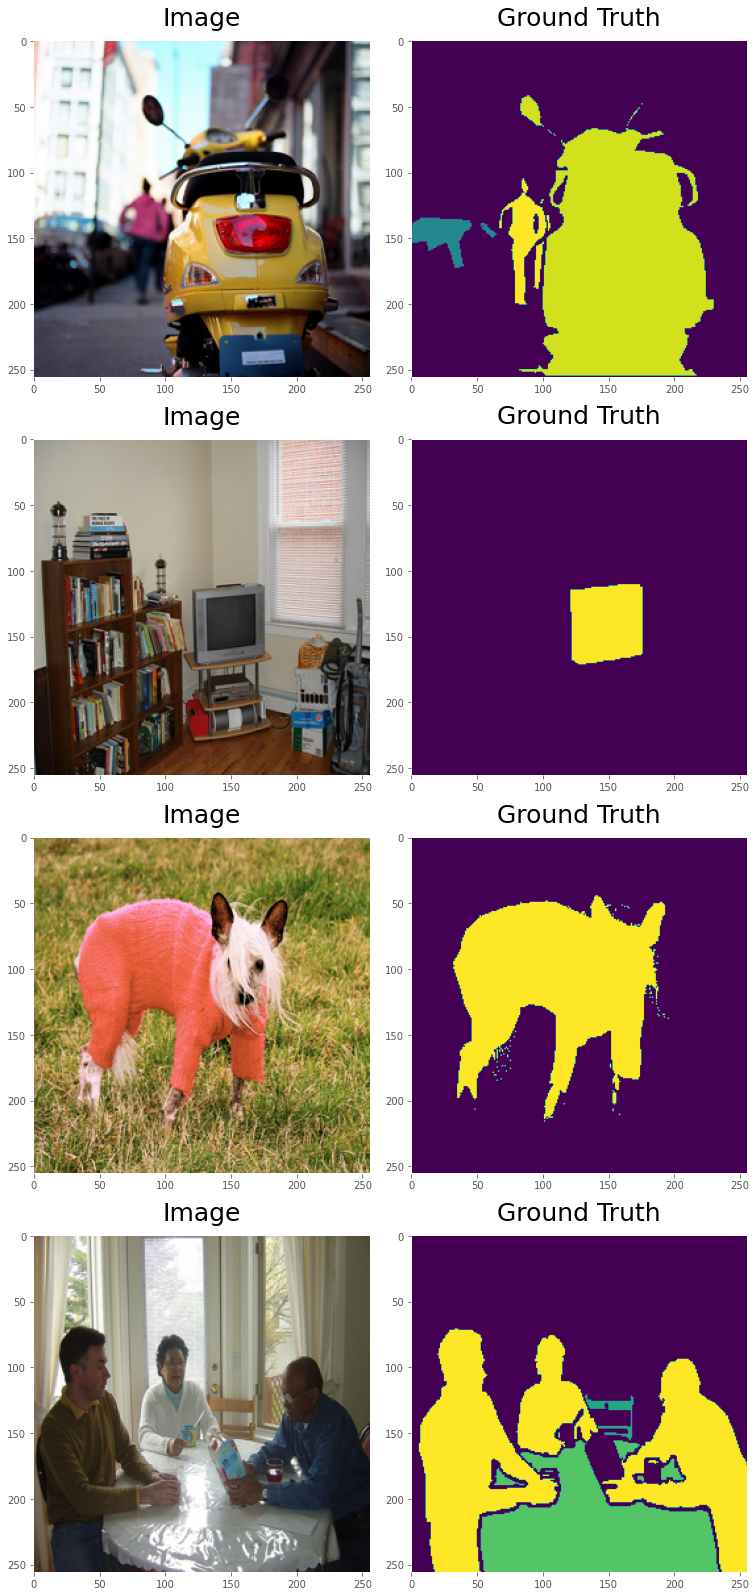

In [13]:
all_images = []

for i in range(len(images)):
    all_images.extend((images[i], masks[i]))
    
plot(all_images, title=['Image', 'Ground Truth'] * len(images), combine='separate', cmap='viridis', ncols=2, figsize=(10, 20))

### Training model

Validation pipeline for training loop

In [14]:
metrics_pipeline = (
     Pipeline()
    .import_model('unet', main_pipeline)
    #.load_model(name='unet', model_class=UNet, path='unet_final.torch')
    #.init_model(name='unet', model_class=UNet, config=config)
    .init_variable('metrics')
    #.init_variable('iou')
    .init_variable('predicted_masks')
    .init_variable('val_loss', [])
    .predict_model('unet',
                   inputs=B('images'),
                   targets=B('my_labels'),
                   outputs=['predictions', 'loss'],
                   save_to=[V('predicted_masks', mode='w'), V('val_loss', mode='a')]
                  )
    .gather_metrics('segmentation',
                    targets=B('my_labels'),
                    predictions=V('predicted_masks'),
                    fmt='logits',
                    num_classes=NUM_CLASSES,
                    axis=1, # ????
                    save_to=V('metrics', mode='u')
                    )
)

val_pipeline = (load_pipeline + metrics_pipeline) << dataset.train

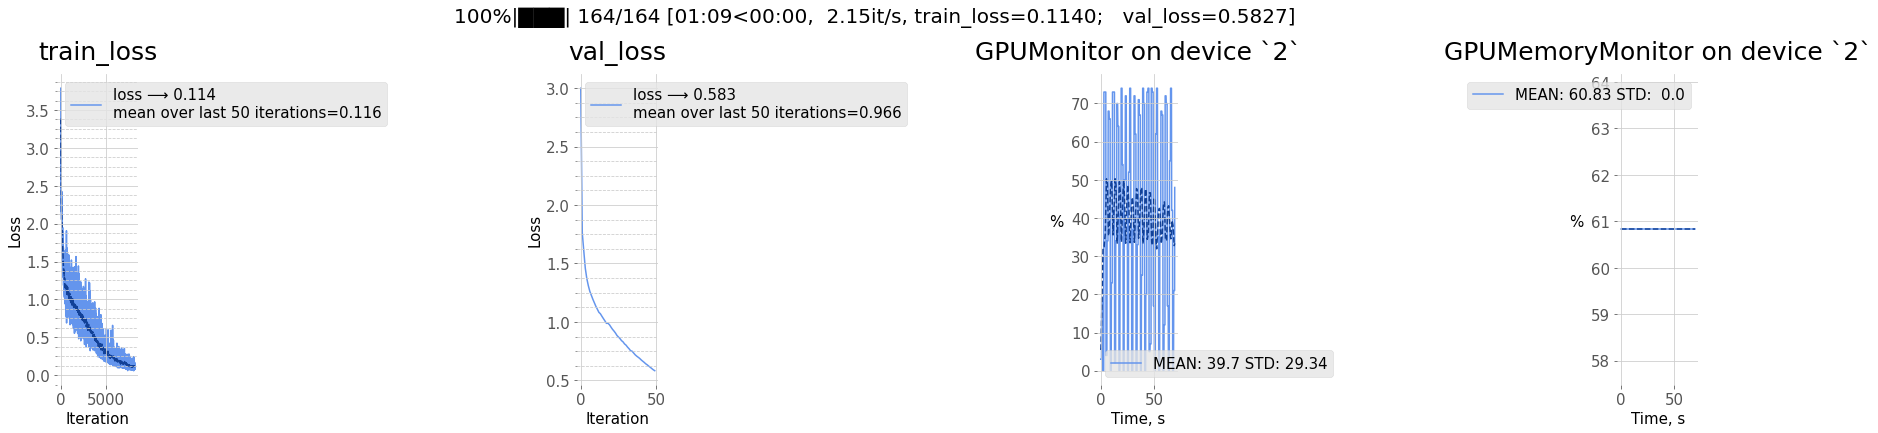

100%|█████████████████████████████████████████| 163/163 [01:08<00:00,  2.37it/s]


In [15]:
path = 'logs/logs_res_unet'
if not os.path.exists(path):
    os.mkdir(path)
    
val_loss_history  = [3] 
#metrics_history = [0]
min_val_loss = np.inf 

train_notifier = {
    'bar': 'n',
    'frequency': FREQUENCY,
    'graphs': [
        {'source': 'train_loss'},
        {'source': val_loss_history, 
         'name': 'val_loss'},
        #{'source': metrics_history, 
        # 'name': 'IoU'},
        {'source': 'gpu'},
        {'source': 'gpu_memory'}
    ],
    #'graphs': ['train_loss', 'val_loss', 'gpu'],
    'savepath': os.path.join(path, 'notifier')
}

for _ in range(NUM_EPOCHS):
    main_pipeline.run(batch_size=BATCH_SIZE, n_epochs=1, shuffle=True, notifier=train_notifier)
    # load_model_now()
    val_pipeline.run(batch_size=BATCH_SIZE, drop_last=True, bar='t')
    #iou = val_pipeline.v('metrics').evaluate('iou', agg='mean', multiclass='macro')
    #metrics_history.append(iou)
    val_loss = np.mean(val_pipeline.v('val_loss'))
    val_loss_history.append(val_loss)
    #main_pipeline.set_variable('val_loss', val_loss, mode='a')
    
    if val_loss < min_val_loss:
        main_pipeline.save_model_now('unet', path='unet_final.torch')
        min_val_loss = val_loss

### Inference 

In [23]:
val_pipeline.run(batch_size=BATCH_SIZE, drop_last=False, bar='t')

IoU_micro = val_pipeline.v('metrics').evaluate('iou', agg='mean', multiclass='micro')
IoU_macro = val_pipeline.v('metrics').evaluate('iou', agg='mean', multiclass='macro')
IoU_per_class = val_pipeline.v('metrics').evaluate('iou', agg='mean', multiclass=None)

100%|█████████████████████████████████████████| 164/164 [01:16<00:00,  2.15it/s]


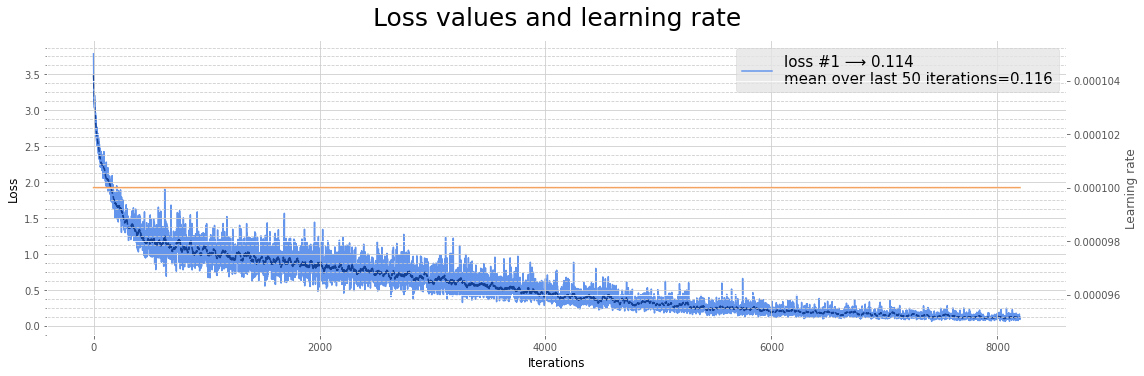

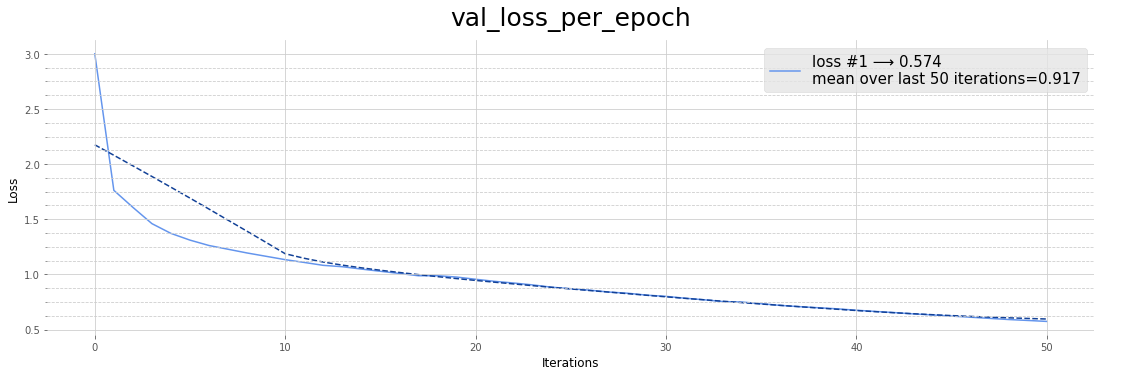

In [20]:
main_pipeline.model.plot_loss()
plot(val_loss_history, mode='loss', title='val_loss_per_epoch')

In [24]:
print(IoU_micro)
print(IoU_macro)
print(IoU_per_class)

0.7687086804014172
0.391683770359433
[0.8701625  0.15447322 0.02596277 0.09603427 0.14358594 0.08008761
 0.20694903 0.16075728 0.18528684 0.07109726 0.07077737 0.13253974
 0.11545446 0.0872929  0.10781629 0.25516736 0.05724979 0.12536729
 0.12560444 0.19116763 0.17972126]


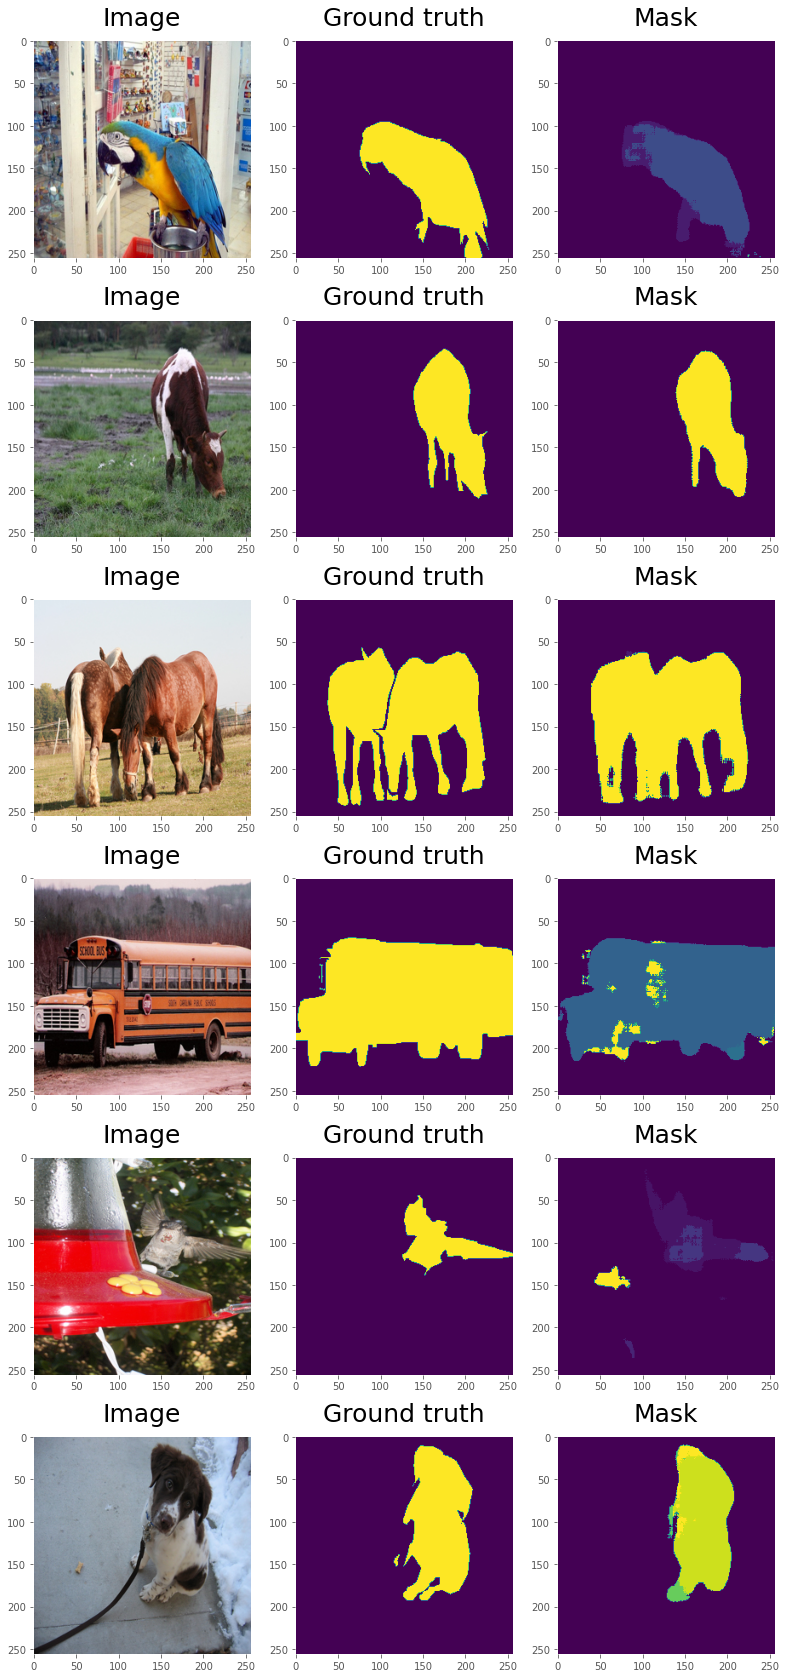

In [ ]:
val_pipeline.reset('iter')
test_batch = val_pipeline.next_batch(6, shuffle=True)
images = test_batch.images
masks = test_batch.my_labels
#val_pipeline.load_model_now(path='')
predicted_masks = val_pipeline.v('predicted_masks').argmax(axis=1)

images = images.transpose((0, 2, 3, 1))

all_images = []

for i in range(len(images)):
    all_images.extend((images[i], masks[i], predicted_masks[i]))

plot(all_images, title=['Image', 'Ground truth', 'Mask'] * len(images), combine='separate', cmap='viridis', ncols=3, figsize=(10, 20))